# Analyse Training Run

This notebook evaluates a completed model training run. It extracts the best epoch statistics, plots the learning curves (Loss, Accuracy, F1), and runs inference on the validation set to generate a Confusion Matrix.

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report

from src.train.load_run import resolve_run_and_checkpoint, load_history, load_run_config
from src.data_loader import FeatureFusionDataset
from src.preprocessing.feature_modes import feature_mode_to_features, feature_mode_to_in_channels, manifest_suffix_for_feature
from src.utils.system_utils import load_yaml

def resolve_feature_manifests_for_run(run_cfg, project_root):
    resolved_cfg = run_cfg.get("resolved", {}) or {}
    dataset_name = run_cfg.get("dataset")
    feature_mode = run_cfg.get("feature_mode", "mel")
    feature_names = feature_mode_to_features(feature_mode)

    primary_manifest_rel = resolved_cfg.get("primary_manifest")
    saved_feature_manifests = resolved_cfg.get("feature_manifests", {}) or {}
    audio_cfg = None

    if primary_manifest_rel:
        manifest_path = project_root / primary_manifest_rel
    else:
        audio_cfg_rel = resolved_cfg.get("audio_config", "src/configs/audio_params.yaml")
        audio_cfg = load_yaml(project_root / audio_cfg_rel) or {}
        base_manifest_rel = audio_cfg.get("datasets", {}).get(dataset_name, {}).get("manifest")
        if not base_manifest_rel:
            raise KeyError(f"Could not resolve manifest for dataset '{dataset_name}'")
        base_manifest = project_root / base_manifest_rel
        primary_suffix = manifest_suffix_for_feature(feature_names[0])
        manifest_path = base_manifest.with_name(f"{dataset_name}_train_{primary_suffix}.csv")

    feature_manifest_paths = {}
    if len(feature_names) == 1 and not saved_feature_manifests:
        return manifest_path, feature_manifest_paths

    if audio_cfg is None:
        audio_cfg_rel = resolved_cfg.get("audio_config", "src/configs/audio_params.yaml")
        audio_cfg = load_yaml(project_root / audio_cfg_rel) or {}

    base_manifest_rel = audio_cfg.get("datasets", {}).get(dataset_name, {}).get("manifest")
    if not base_manifest_rel:
        raise KeyError(f"Could not resolve manifest set for dataset '{dataset_name}'")
    base_manifest = project_root / base_manifest_rel

    for feature_name in feature_names:
        if feature_name == feature_names[0]:
            feature_manifest_paths[feature_name] = manifest_path
            continue

        saved_path = saved_feature_manifests.get(feature_name)
        if saved_path:
            feature_manifest_paths[feature_name] = project_root / saved_path
            continue

        suffix = manifest_suffix_for_feature(feature_name)
        feature_manifest_paths[feature_name] = base_manifest.with_name(f"{dataset_name}_train_{suffix}.csv")

    return manifest_path, feature_manifest_paths

# --- CONFIGURATION ---

# RUN_INPUT = "../models/saved_weights/irmas_single_label_mel_cnn"
RUN_INPUT = "../models/saved_weights/irmas_pretrain_mel_densenet"
PREFERRED_WEIGHT = "best_val.pt"


### 1. Training Statistics & Learning Curves

--- Best Validation Performance ---
epoch           5.000000
val_loss        1.021570
val_acc         0.665175
val_macro_f1    0.654804


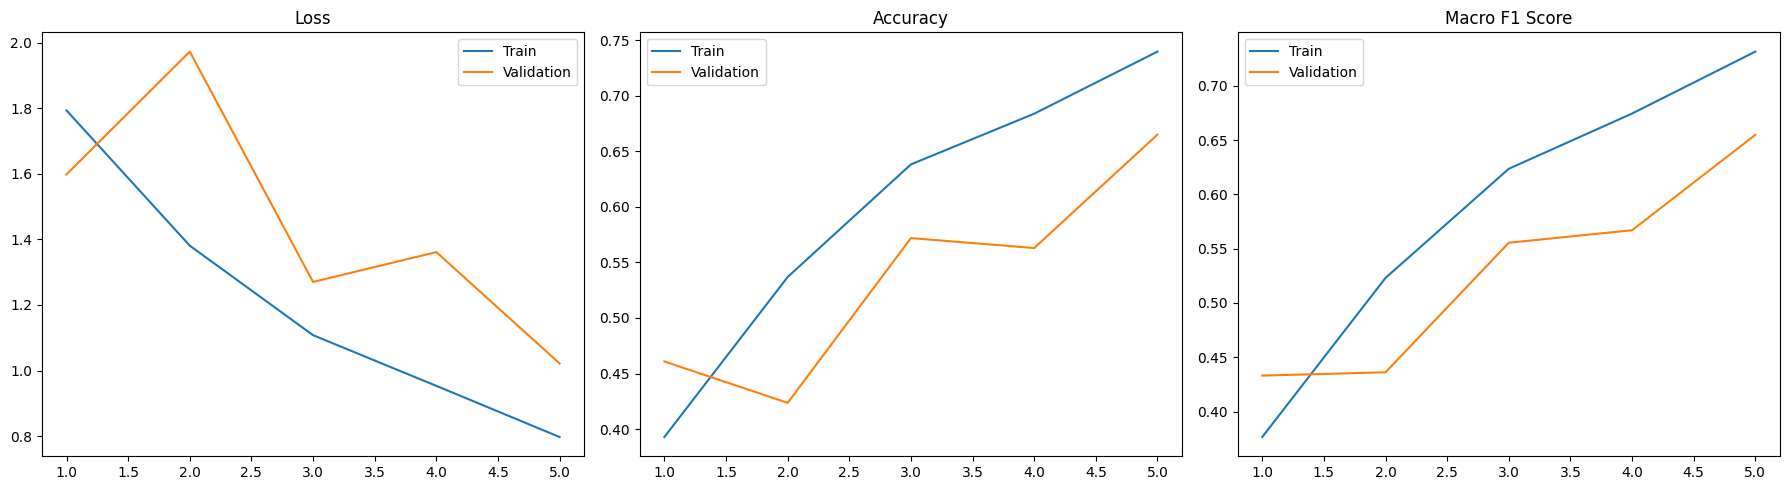

In [5]:
resolved = resolve_run_and_checkpoint(RUN_INPUT, PREFERRED_WEIGHT)
run_cfg = load_run_config(resolved["run_cfg_path"])
history_df, _, _ = load_history(resolved["history_csv_path"], resolved["ckpt_path"])

if not history_df.empty:
    best_epoch = history_df["val_loss"].idxmin()
    best_stats = history_df.iloc[best_epoch][["epoch", "val_loss", "val_acc", "val_macro_f1"]]
    print("--- Best Validation Performance ---")
    print(best_stats.to_string())
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Validation')
    axes[0].set_title('Loss')
    axes[0].legend()
    
    if 'train_acc' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Train')
        axes[1].plot(history_df['epoch'], history_df['val_acc'], label='Validation')
        axes[1].set_title('Accuracy')
        axes[1].legend()
        
    if 'train_macro_f1' in history_df.columns:
        axes[2].plot(history_df['epoch'], history_df['train_macro_f1'], label='Train')
        axes[2].plot(history_df['epoch'], history_df['val_macro_f1'], label='Validation')
        axes[2].set_title('Macro F1 Score')
        axes[2].legend()
        
    plt.tight_layout()
    plt.show()

### 2. Validation Inference & Confusion Matrix

Loading model and running inference on validation set...


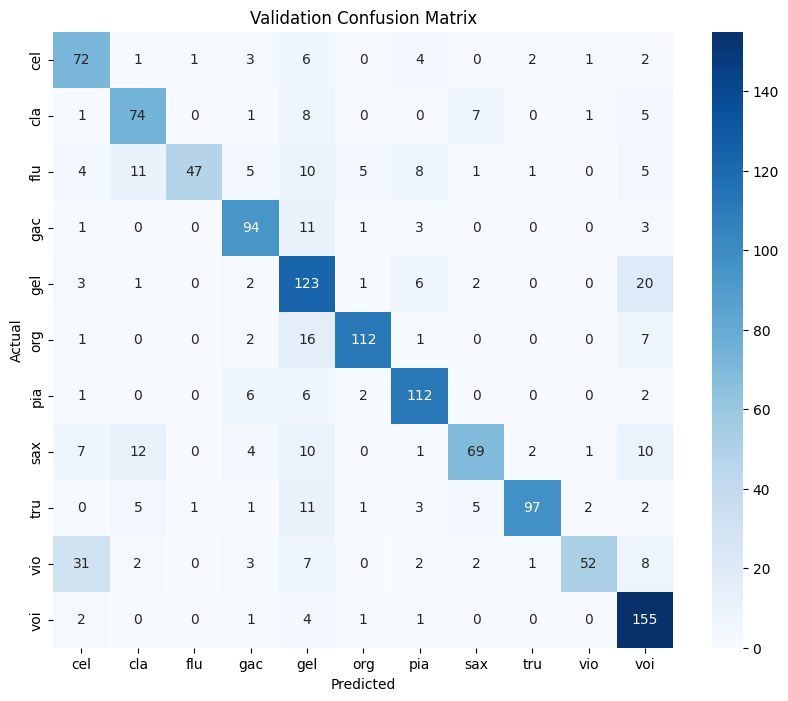


Classification Report:

              precision    recall  f1-score   support

         cel       0.59      0.78      0.67        92
         cla       0.70      0.76      0.73        97
         flu       0.96      0.48      0.64        97
         gac       0.77      0.83      0.80       113
         gel       0.58      0.78      0.66       158
         org       0.91      0.81      0.85       139
         pia       0.79      0.87      0.83       129
         sax       0.80      0.59      0.68       116
         tru       0.94      0.76      0.84       128
         vio       0.91      0.48      0.63       108
         voi       0.71      0.95      0.81       164

    accuracy                           0.75      1341
   macro avg       0.79      0.74      0.74      1341
weighted avg       0.78      0.75      0.75      1341



In [6]:
from src.models.builder import build_model


print("Loading model and running inference on validation set...")
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

classes = run_cfg.get("classes", [])
feature_mode = run_cfg.get("feature_mode", "mel")
task_mode = run_cfg.get("task_mode", "single_label")

# 1. Setup Dataset from Saved Split
split_data = torch.load(resolved["split_path"], map_location="cpu", weights_only=False)
val_indices = split_data["val_indices"]

manifest_path, feature_manifest_paths = resolve_feature_manifests_for_run(run_cfg, resolved["project_root"])
dataset = FeatureFusionDataset(
    feature_mode=feature_mode,
    manifest_path=manifest_path,
    class_names=classes,
    feature_manifest_paths=feature_manifest_paths or None,
    project_root=str(resolved["project_root"])
)
val_ds = Subset(dataset, val_indices)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# 2. Load Model Weights
in_ch = feature_mode_to_in_channels(feature_mode)
model = build_model(run_cfg["model"]["backbone"], in_ch, len(classes), run_cfg["model"])
ckpt = torch.load(resolved["ckpt_path"], map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

# 3. Run Inference
all_preds, all_targets = [], []

with torch.no_grad():
    for x, y_raw in val_loader:
        x = x.to(device)
        logits = model(x)
        
        if task_mode == "single_label":
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = (torch.argmax(y_raw, dim=1) if y_raw.ndim > 1 else y_raw).cpu().numpy()
        else:
            preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
            targets = y_raw.cpu().numpy()
            
        all_preds.extend(preds)
        all_targets.extend(targets)

# 4. Plot Results
if task_mode == "single_label":
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Validation Confusion Matrix')
    plt.show()
    
    print("\nClassification Report:\n")
    print(classification_report(all_targets, all_preds, target_names=classes))
else:
    print("\nMulti-Label Classification Report:\n")
    print(classification_report(all_targets, all_preds, target_names=classes, zero_division=0))